#  Customer Churn Analysis of Telecom Industry

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\DHANYA\Downloads\Telco-Customer-Churn.csv")
print("Dataset is loaded successfully!")

Dataset is loaded successfully!


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Step 1 - Data Cleaning with Python

In [3]:
# To confirm there is no missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
# To check there is no duplicate values
df.duplicated().sum()

np.int64(0)

In [4]:
# Converting data type of TotalCharges from object to float

# Strip whitespace and replace empty strings with NaN
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', np.nan)

# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Handle missing values (drop or fill)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


C:\Users\DHANYA\AppData\Local\Temp\ipykernel_12092\2780390666.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [5]:
# Standardize column names 
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_',regex=False)

In [21]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

### Step 2 - EDA(Explortory Data Analysis)

In [7]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#### Insights
- Only 16% are senior citizen.
- Average tenure is 2 and a half years (2.5 years) but range upto 6 years.
- The monthly charges vary between 18 to 119 (in dollars).
- The total charges depends on tenure and monthly charges varys between 19 to 8685 (in dollars).

In [8]:
df.describe(include=object)

,customerid,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


#### Insights
- Most customers are male
- Majority do not have dependents
- Most have phone service
- The most common internet type is fiber optic
- Majority do not subscribe to extra services (like online security, backup, device protection, tech support, streaming)
- Most are on month to month contracts
- Majority prefer paperless billing
- Most common payment method is electronic check
- Majority of customers did not churn


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

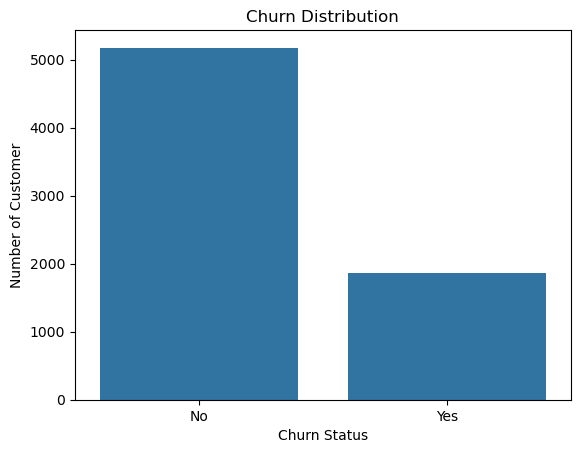

In [11]:
# Distribution of Churn 
sns.countplot(x ='churn', data = df)
plt.title('Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customer')
plt.show()

In [13]:
# Overall Churn Rate
churn_count = df['churn'].value_counts()
churn_rate = churn_count['Yes']/churn_count.sum()*100
print('The overall churn rate is',churn_rate)

The overall churn rate is 26.536987079369588


#### Insight:
- This means about 27% of customer left or stopped their subscription or service whereas the remaining 73% is retained.

In [19]:
# Demographics V/S Churn
demographics = ['gender', 'seniorcitizen', 'partner', 'dependents' ]
for col in demographics:
    churn_rate = df.groupby(col)['churn'].value_counts(normalize = True).unstack() *100
    print(churn_rate)

churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338
churn                 No        Yes
seniorcitizen                      
0              76.393832  23.606168
1              58.318739  41.681261
churn           No        Yes
partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903
churn              No        Yes
dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


#### Insights
- Gender: Both the percentage of male and female who left the subscription is 26.2% showing gender is not a significant driver.
- Senior Citizens: More than non-Senior Citizen (around 24%), Senior Citizens(around 42%) left the subscription, making them a clear risk group.
- Partner: Customer without partners churn (about 33%) than with partners (about 19.7%), suggesting family/partner bundles reduce churn.
- Dependents: Customers without dependents (about 31%) churn more with dependents (about 15%), this indicate that families are the loyal customer categories.

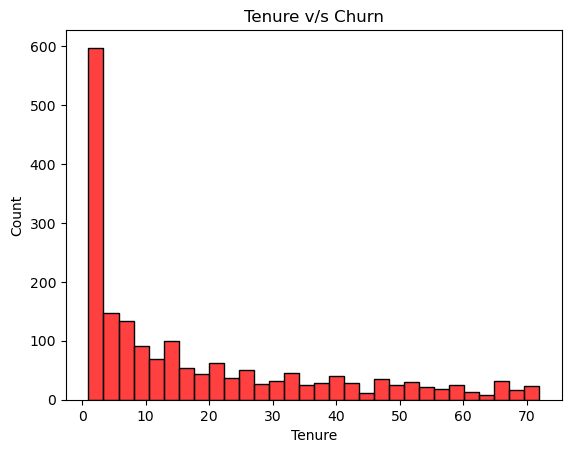

In [26]:
# Tenure v/s Churn
sns.histplot(df[df['churn']== 'Yes']['tenure'], bins = 30, color = 'red')
plt.title('Tenure v/s Churn')
plt.xlabel('Tenure')
plt.show()

#### Insight
- From this diagram it is clear that long term customers are more loyal than new customers.

In [7]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

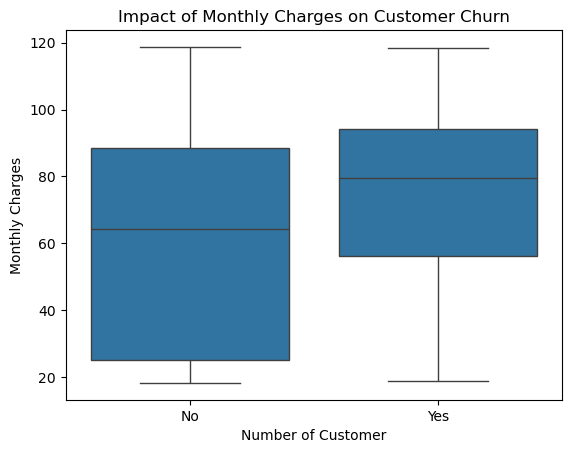

In [8]:
# Monthly Charges v/s Churn
sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.title('Impact of Monthly Charges on Customer Churn')
plt.xlabel('Number of Customer')
plt.ylabel('Monthly Charges')
plt.show()


#### Insight
- From the diagram it is clear that customers who charged higher leaved the subscription than customer who charged less.

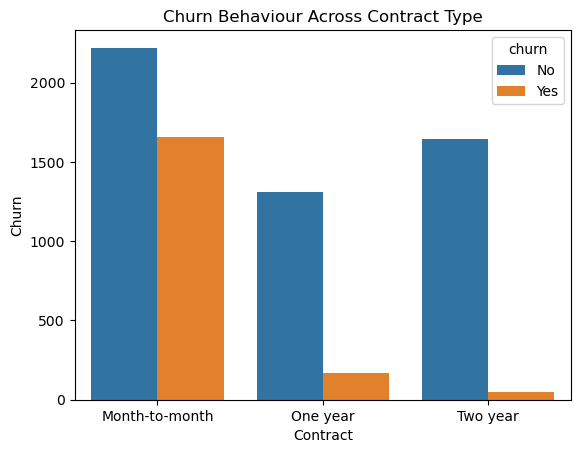

In [12]:
# Contract type vs churn
sns.countplot(x='contract', hue ='churn', data=df)
plt.title ('Churn Behaviour Across Contract Type')
plt.xlabel('Contract')
plt.ylabel('Churn')
plt.show()

#### Insight
- Most customers who both churned and retained were on month‑to‑month contracts, indicating this contract type carries the highest churn risk. In contrast, customers with two‑year contracts showed the lowest churn, suggesting long‑term commitments improve retention. One‑year contracts fall in between, with churn higher than two‑year but lower than month‑to‑month.

### Step 3 - Export as CSV file

In [15]:
df.to_csv("cleaned_CustomerChurnAnalysis.csv", index=False)
print('File exported sucessfully!')

File exported sucessfully!
